# BGL Anomaly Detection: Direct Self-Reflective RAG

**Experiment:** E06 — Self-Reflective RAG anomaly detection.  No ML training.
**Strategy:** Initial RAG inference followed by an iterative self-critique and
revision loop (up to 2 reflections) when the model's confidence is below
the threshold (0.75).
**Dataset:** BGL
**Embedding model:** `BAAI/bge-base-en-v1.5`
**Generation model:** `llama-3.1-8b-instant` via Groq API
**Evaluation model:** `qwen/qwen3-32b` via Groq API (LLM-as-judge)
**Vector store:** Qdrant (persistent, shared KB)
**Reference:** E03 (Vanilla RAG baseline)


In [1]:
# =============================================================================
# CELL 1 — PACKAGE INSTALLATION
# =============================================================================
import subprocess
import sys


def install_packages(pkgs):
    for p in pkgs:
        print(f"Installing: {p}")
        r = subprocess.run(
            [sys.executable, "-m", "pip", "install", p, "-q"],
            capture_output=True, text=True,
        )
        print("  OK" if r.returncode == 0 else f"  WARN: {r.stderr[:120]}")

install_packages([
    "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn",
    "groq", "tqdm", "sentence-transformers", "qdrant-client",
])
print("\nAll packages ready.")


Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: groq
  OK
Installing: tqdm
  OK
Installing: sentence-transformers
  OK
Installing: qdrant-client
  OK

All packages ready.


Prompts loaded from : c:\Users\Abhishek Mulay\Desktop\UpgradAIML\Masters\Topics\Revised_Topics\Topic 1\LogSense\Implementation\Experiments\src\Prompts
  Primary Groq keys : 5
  Fallback keys     : 5

Loading BGL structured log ...
  Rows: 2000,  Normal: 1857,  Anomalous: 143

Creating test split ...
  Test Normal    : 200  (93.0%)
  Test Anomalous : 15  (7.0%)
  Test Total     : 215

Connecting to persistent Qdrant KB ...
Collection                Points
----------------------------------
bgl_logs                    3765
bgl_architecture             402
bgl_severity                  80
bgl_rca                       75
hdfs_logs                    300
hdfs_architecture             27
hdfs_severity                 13
hdfs_rca                      15
role_sre                      33
role_devops                   38
  KB client ready

Running parallel Self-Reflective RAG inference on 215 test samples ...
  MAX_REFLECTIONS                : 2
  REFLECTION_CONFIDENCE_THRESHOLD: 0.75


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3441.99it/s]s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8885.58it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3263.41it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UN

  [rate-limit] Rotated to fallback key (attempt 1/9)


Self-Reflective RAG Inference:  16%|█▋        | 35/215 [02:21<10:12,  3.40s/it]

  [rate-limit] Rotated to fallback key (attempt 1/9)


...

  [rate-limit] Rotated to fallback key (attempt 1/9)


RAG Evaluation:  80%|████████  | 12/15 [14:46<03:44, 74.82s/it]

  [rate-limit] All keys exhausted — sleeping 60s (attempt 1/9)


RAG Evaluation: 100%|██████████| 15/15 [18:40<00:00, 74.67s/it]



  RETRIEVAL METRICS  [BGL]  (n=15)
  MRR                   : 1.0000
  Hit Rate @5           : 1.0000
  Context Precision     : 1.0000

  RAGAs METRICS
  Faithfulness          : 0.4933
  Answer Relevance      : 0.8733
  Context Precision     : 1.0000
  Context Recall        : 0.9733

  ADDITIONAL RAG METRICS
  Root Cause Score      : 0.9900
  Evidence Support      : 0.3867
  Severity Agreement    : 1.0000
  Consistency Score     : 1.0000
  Role Appr. (SRE)      : 0.5800
  Role Appr. (DevOps)   : 0.6200
  Completeness Score    : 0.9267


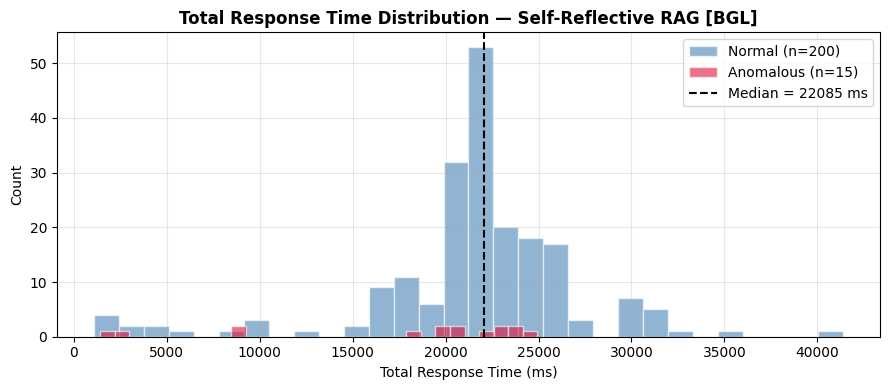

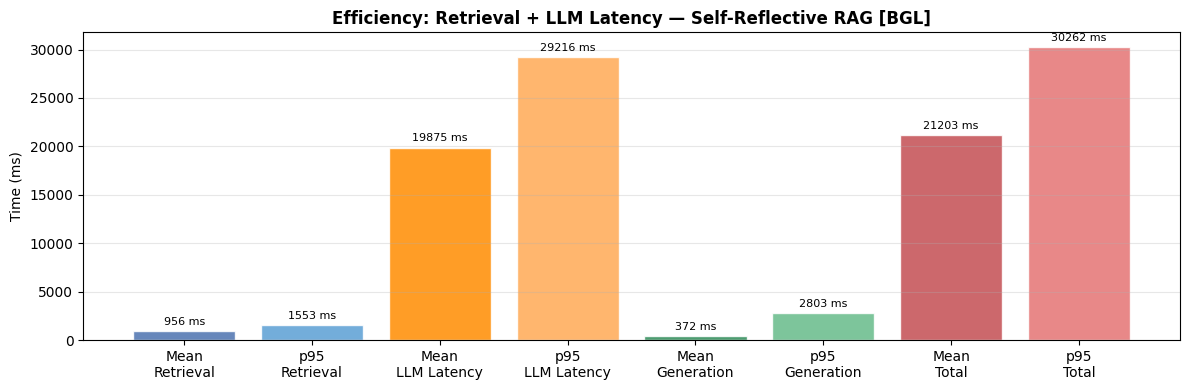

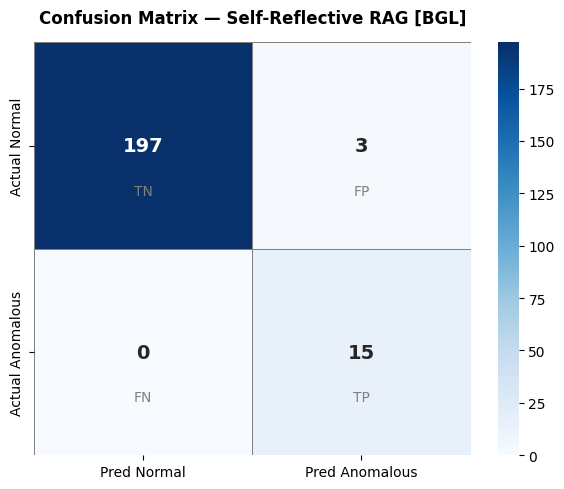

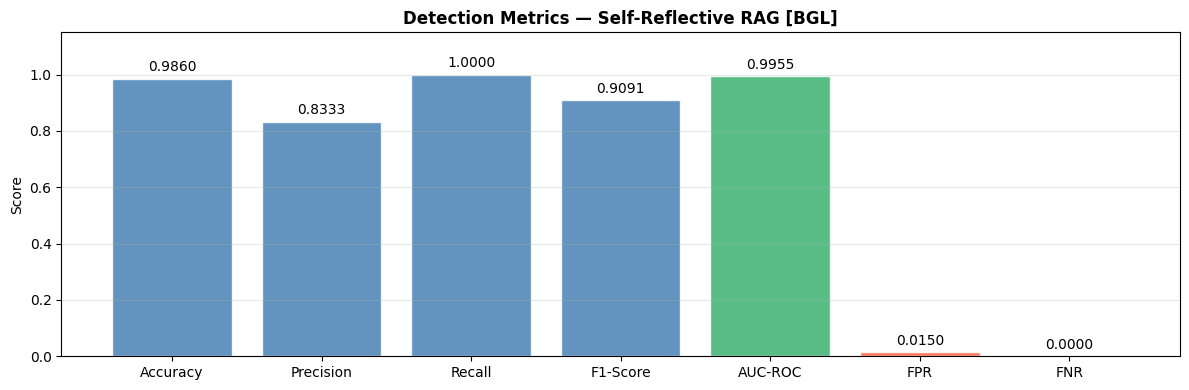

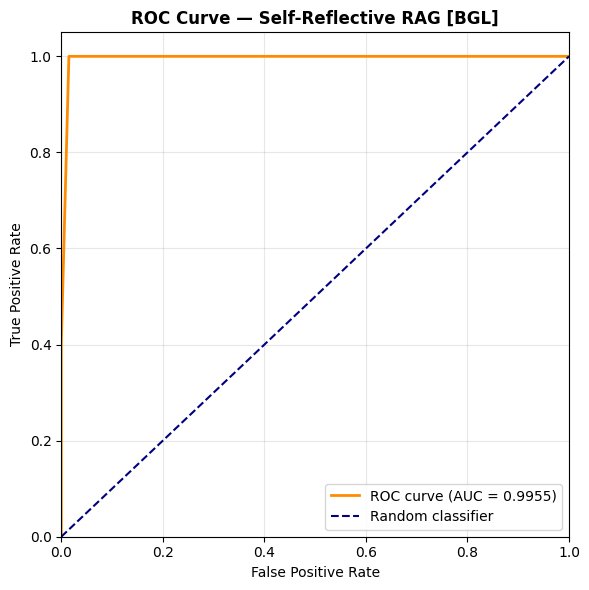

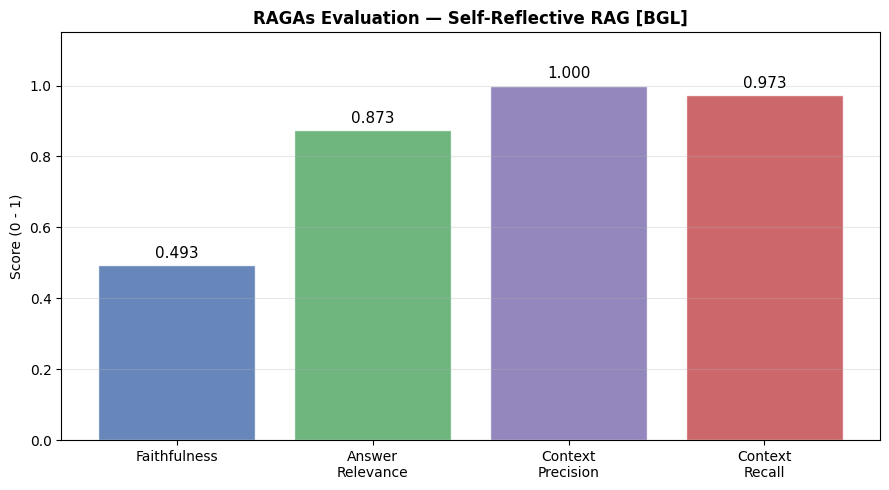

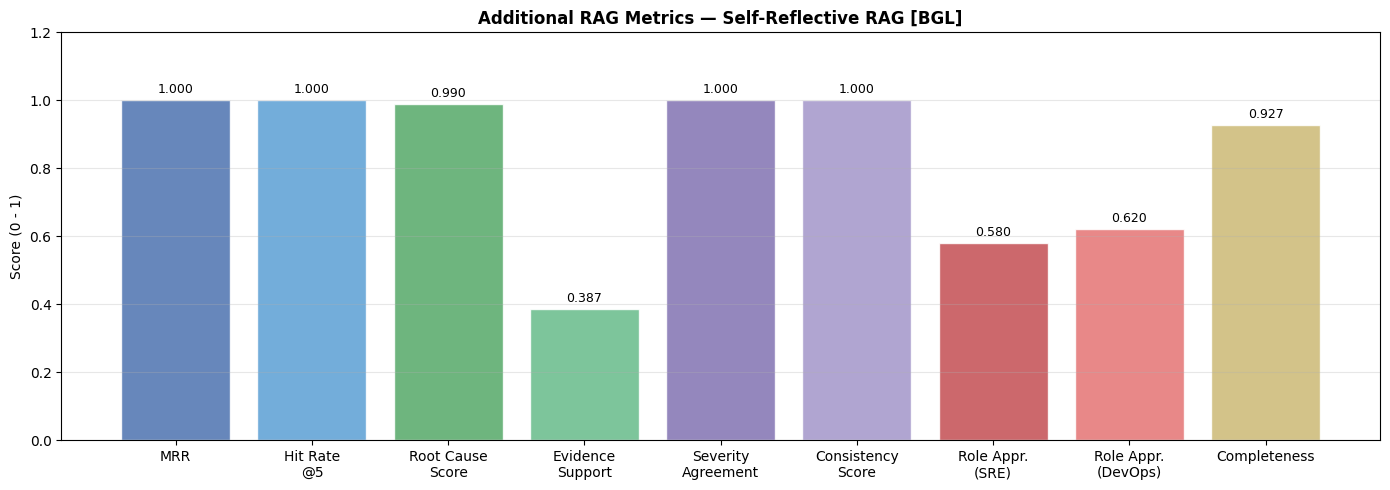


All visualisations complete.


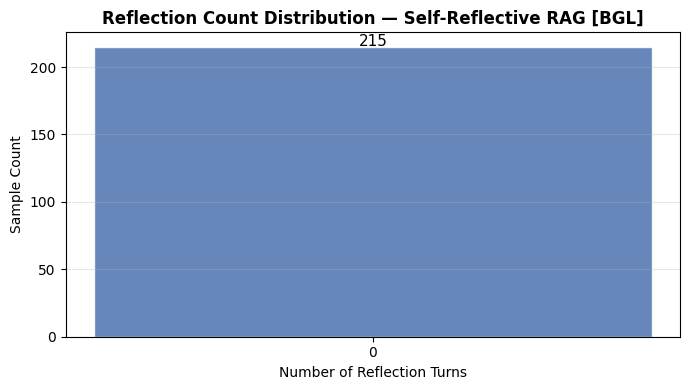

  Saved: bgl_self_reflective_rag_reflection_dist.png


In [2]:
# =============================================================================
# CELL 2 — IMPORTS, CONFIGURATION, DATA LOADING, KB,
#           RETRIEVAL, SELF-REFLECTIVE INFERENCE, METRICS, VIZ
# =============================================================================
# -- Standard library imports -------------------------------------------------
import json
import os
import re
import sys
import time
import warnings
from typing import Any, Dict, List, Optional, Tuple

# -- Third-party imports ------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from groq import Groq
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

# -- Persistent KB (src/KnowledgeBase/) ---------------------------------------
_KB_DIR = os.path.abspath(
    os.path.join(os.getcwd(), "..", "..", "KnowledgeBase")
)
if _KB_DIR not in sys.path:
    sys.path.insert(0, _KB_DIR)
from kb_utils import KBClient

# -- Shared prompt repository (src/Prompts/) ----------------------------------
_PROMPTS_DIR = os.path.abspath(
    os.path.join(os.getcwd(), "..", "..", "Prompts")
)
if _PROMPTS_DIR not in sys.path:
    sys.path.insert(0, _PROMPTS_DIR)

from detection_prompts import (
    BGL_CONFIG,
    build_rag_system_prompt,
    format_retrieved_context,
)
from eval_prompts import (
    JUDGE_SYSTEM_PROMPT,
    build_faithfulness_prompt,
    build_answer_relevance_prompt,
    build_sre_appropriateness_prompt,
    build_devops_appropriateness_prompt,
    build_context_recall_prompt,
    build_root_cause_score_prompt,
    build_evidence_support_prompt,
    build_completeness_prompt_rag,
)
print(f"Prompts loaded from : {_PROMPTS_DIR}")
RAG_SYSTEM_PROMPT = build_rag_system_prompt(BGL_CONFIG)
# =============================================================================
# SECTION 1 — CONFIGURATION
# =============================================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATASET = "BGL"

EMBED_MODEL_NAME = "BAAI/bge-base-en-v1.5"
LLM_MODEL        = "llama-3.1-8b-instant"
EVAL_MODEL       = "qwen/qwen3-32b"

N_FEW_SHOT_NORMAL = 5
N_FEW_SHOT_ANOM   = 5

TEST_NORMAL_CAP  = 200
TEST_ANOMALY_CAP = 15

RETRIEVAL_K           = 5
RETRIEVAL_K_KNOWLEDGE = 2
RETRIEVAL_K_ROLE      = 2

MAX_RETRIES     = 3
RETRY_DELAY_S   = 5
REQUEST_DELAY_S = 0.5
LLM_MAX_TOKENS  = 900
LLM_TEMPERATURE = 0.0
EVAL_MAX_TOKENS = 1024


def _load_groq_key(n: int) -> Optional[str]:
    p = os.path.abspath(
        os.path.join(
            os.getcwd(), "..", "..", "Keys", f"groq_key_{n}.txt"
        )
    )
    try:
        with open(p) as _f:
            return _f.read().strip()
    except FileNotFoundError:
        return None


_ALL_PRIMARY  = [
    k for k in [_load_groq_key(i) for i in range(1, 6)] if k
]
_ALL_FALLBACK = [
    k for k in [_load_groq_key(i) for i in range(6, 11)] if k
]

if not _ALL_PRIMARY:
    raise FileNotFoundError(
        "No primary Groq keys found. "
        "Expected src/Keys/groq_key_1.txt ... groq_key_5.txt"
    )

GROQ_API_KEY = _ALL_PRIMARY[0]

DATASET_CONFIG = {
    "structured_log_path": (
        "../../../Datasets/BGL/Processed/BGL_2k.log_structured.csv"
    ),
    "templates_path": (
        "../../../Datasets/BGL/Processed/BGL_2k.log_templates.csv"
    ),
    "label_col":     "Label",
    "normal_value":  "-",
    "event_id_col":  "EventId",
    "component_col": "Component",
    "level_col":     "Level",
    "content_col":   "Content",
    "template_col":  "EventTemplate",
}

print(f"  Primary Groq keys : {len(_ALL_PRIMARY)}")

print(f"  Fallback keys     : {len(_ALL_FALLBACK)}")
# =============================================================================
# SECTION 2 — DATA LOADING
# =============================================================================


def build_log_text(row: pd.Series) -> str:
    comp = str(row.get("Component", "")).strip()
    lvl  = str(row.get("Level", "")).strip()
    cont = str(row.get("Content", "")).strip()
    tmpl = str(row.get("EventTemplate", "")).strip()
    return f"[{comp}] [{lvl}] {cont} | Template: {tmpl}"


def load_bgl(config: Dict) -> pd.DataFrame:
    print("\nLoading BGL structured log ...")
    df_logs = pd.read_csv(config["structured_log_path"])
    df_tmpl = pd.read_csv(config["templates_path"])
    df = df_logs.merge(
        df_tmpl, on=config["event_id_col"], how="left",
        suffixes=("", "_tmpl"),
    )
    df["is_normal"]    = df[config["label_col"]] == config["normal_value"]
    df["binary_label"] = (~df["is_normal"]).astype(int)
    df["log_text"]     = df.apply(build_log_text, axis=1)
    n_norm = int(df["is_normal"].sum())
    n_anom = int((~df["is_normal"]).sum())
    print(f"  Rows: {len(df)},  Normal: {n_norm},  Anomalous: {n_anom}")
    return df


df = load_bgl(DATASET_CONFIG)


# =============================================================================
# SECTION 3 — TEST SPLIT
# =============================================================================
def create_test_split(
    df: pd.DataFrame,
    n_few_shot_normal: int,
    n_few_shot_anom: int,
    test_normal_cap: int,
    test_anomaly_cap: int,
    seed: int = 42,
) -> pd.DataFrame:
    df_n = (
        df[df["is_normal"]]
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )
    df_a = (
        df[~df["is_normal"]]
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )
    rem_n = df_n.iloc[n_few_shot_normal:].reset_index(drop=True)
    rem_a = df_a.iloc[n_few_shot_anom:].reset_index(drop=True)
    n_t_n = min(test_normal_cap,  len(rem_n))
    n_t_a = min(test_anomaly_cap, len(rem_a))
    if n_t_a < test_anomaly_cap:
        print(
            f"  WARNING: only {n_t_a} anomalies available "
            f"(requested {test_anomaly_cap})."
        )
    return (
        pd.concat(
            [rem_n.iloc[:n_t_n], rem_a.iloc[:n_t_a]],
            ignore_index=True,
        )
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )


print("\nCreating test split ...")
test_df = create_test_split(
    df, N_FEW_SHOT_NORMAL, N_FEW_SHOT_ANOM,
    TEST_NORMAL_CAP, TEST_ANOMALY_CAP, RANDOM_SEED,
)
n_tn = int(test_df["is_normal"].sum())
n_ta = int((~test_df["is_normal"]).sum())
print(f"  Test Normal    : {n_tn}  ({n_tn / len(test_df) * 100:.1f}%)")
print(f"  Test Anomalous : {n_ta}  ({n_ta / len(test_df) * 100:.1f}%)")
print(f"  Test Total     : {len(test_df)}")


# =============================================================================
# SECTION 4 — PERSISTENT KNOWLEDGE BASE CLIENT
# =============================================================================
print("\nConnecting to persistent Qdrant KB ...")
kb = KBClient()
kb.collection_stats()
print("  KB client ready")


def _format_knowledge_context(hits: List[Dict]) -> str:
    if not hits:
        return "(none)"
    lines = []
    for h in hits:
        cat     = h.get("category", "").upper()
        section = h.get("section", "")
        label   = f" | {section}" if section else ""
        text    = h["text"][:400]
        lines.append(f"[{cat}{label} | score={h['score']:.3f}]\n{text}")
    return "\n\n".join(lines)


def _build_multi_user_prompt(
    log_text: str,
    log_hits: List[Dict],
    system_hits: List[Dict],
    role_hits: List[Dict],
) -> str:
    log_ctx    = (
        format_retrieved_context(log_hits) if log_hits else "(none)"
    )
    system_ctx = _format_knowledge_context(system_hits)
    role_ctx   = _format_knowledge_context(role_hits)
    return (
        f"Log entry to analyze:\n{log_text}\n\n"
        f"[A] Similar log examples from knowledge base:\n"
        f"{log_ctx}\n\n"
        "[B] System knowledge context "
        "(architecture, severity taxonomy, RCA examples):\n"
        f"{system_ctx}\n\n"
        "[C] Role scope reference — use to understand each role's "
        "responsibilities; do not copy verbatim — derive specific "
        f"actions from the log evidence above:\n{role_ctx}"
    )


# =============================================================================
# SECTION 5 — RETRIEVAL (identical to E03 Vanilla RAG)
# =============================================================================

def retrieve(
    query_text: str,
) -> Tuple[List[Dict], List[Dict], List[Dict]]:
    """Standard dense retrieval from the persistent KB (same as E03)."""
    raw_logs = kb.query_bgl_logs(query_text, top_k=RETRIEVAL_K)
    log_hits = [
        {
            "log_text":     h["text"],
            "label":        h["label"],
            "binary_label": 0 if h["label"] == "Normal" else 1,
            "score":        h["score"],
            "rank":         idx + 1,
        }
        for idx, h in enumerate(raw_logs)
    ]

    raw_system = kb.query_multi(
        ["bgl_architecture", "bgl_severity", "bgl_rca"],
        query_text,
        top_k_per_collection=RETRIEVAL_K_KNOWLEDGE,
    )
    system_hits = [
        {
            "text":     h["text"],
            "category": h.get("category", ""),
            "section":  h.get("section", "") or h.get("rca_section", ""),
            "score":    h["score"],
        }
        for h in raw_system
    ]

    raw_roles = kb.query_multi(
        ["role_sre", "role_devops"],
        query_text,
        top_k_per_collection=RETRIEVAL_K_ROLE,
    )
    role_hits = [
        {
            "text":     h["text"],
            "category": h.get("category", ""),
            "section":  h.get("section", ""),
            "score":    h["score"],
        }
        for h in raw_roles
    ]

    return log_hits, system_hits, role_hits


# =============================================================================
# SECTION 7 — GROQ CLIENT AND API HELPERS
# =============================================================================
import threading

N_PARALLEL_WORKERS = min(5, len(_ALL_PRIMARY))

_fallback_lock = threading.Lock()
_fallback_pool = list(_ALL_FALLBACK)

_worker_key  = threading.local()
_assign_lock = threading.Lock()
_assign_idx  = [0]


def _init_worker_key() -> None:
    if not hasattr(_worker_key, "current"):
        with _assign_lock:
            idx     = _assign_idx[0] % len(_ALL_PRIMARY)
            stagger = _assign_idx[0]
            _assign_idx[0] += 1
        time.sleep(stagger * 1.0)
        _worker_key.current = _ALL_PRIMARY[idx]


def _rotate_to_fallback() -> bool:
    with _fallback_lock:
        if _fallback_pool:
            _worker_key.current = _fallback_pool.pop(0)
            return True
    return False


def _is_rate_limit(exc: Exception) -> bool:
    s = type(exc).__name__ + " " + str(exc)
    return (
        "ratelimit" in s.lower()
        or "rate_limit" in s.lower()
        or "429" in s
    )


def call_groq(
    system_prompt: str,
    user_message: str,
    model: str,
    max_tokens: int = LLM_MAX_TOKENS,
    temperature: float = LLM_TEMPERATURE,
) -> Tuple[Optional[str], float, float]:
    _init_worker_key()
    budget = MAX_RETRIES + len(_ALL_FALLBACK) + 1
    for attempt in range(budget):
        try:
            client = Groq(api_key=_worker_key.current)
            t0     = time.perf_counter()
            resp   = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": user_message},
                ],
                max_tokens=max_tokens,
                temperature=temperature,
            )
            t1    = time.perf_counter()
            total = (t1 - t0) * 1000.0
            usage = resp.usage
            c_tok = usage.completion_tokens if usage else 1
            p_tok = usage.prompt_tokens if usage else 0
            gen_ms = total * (c_tok / ((p_tok + c_tok) or 1))
            return (
                resp.choices[0].message.content.strip(),
                total - gen_ms,
                gen_ms,
            )
        except Exception as e:
            if _is_rate_limit(e):
                if _rotate_to_fallback():
                    print(
                        f"  [rate-limit] Rotated to fallback key "
                        f"(attempt {attempt + 1}/{budget})",
                        flush=True,
                    )
                    continue
                print(
                    f"  [rate-limit] All keys exhausted — "
                    f"sleeping 60s (attempt {attempt + 1}/{budget})",
                    flush=True,
                )
                time.sleep(60)
            else:
                time.sleep(RETRY_DELAY_S * min(attempt + 1, 5))
    print(
        f"  [call-groq] All {budget} attempts failed — returning None",
        flush=True,
    )
    return None, 0.0, 0.0


def _strip_thinking(raw: str) -> str:
    stripped = re.sub(
        "<think>.*?</think>", "", raw, flags=re.DOTALL
    ).strip()
    return stripped if stripped else raw


# =============================================================================
# SECTION 8 — RESPONSE PARSER
# =============================================================================


def _compute_risk(si: Any, et: Any, cp: Any) -> Dict:
    si  = max(1, min(4, int(si)))
    et  = max(1, min(4, int(et)))
    cp  = max(1, min(4, int(cp)))
    tot = round(si * 0.4 + et * 0.3 + cp * 0.2, 3)
    lvl = "High" if tot >= 2.8 else ("Medium" if tot >= 1.8 else "Low")
    return {
        "system_impact": si, "error_type": et, "cascade_potential": cp,
        "total_score": tot, "risk_level": lvl,
    }


def parse_rag_response(raw: Optional[str]) -> Dict:
    default = {
        "label": "Normal", "confidence": 0.5,
        "anomaly_explanation": "",
        "rca_summary": "", "rca_detailed": "",
        "rca_confidence_level": "", "rca_confidence_reasoning": "",
        "rca_causal_chain": [], "rca_supporting_evidence": [],
        "risk_system_impact": 0, "risk_error_type": 0,
        "risk_cascade_potential": 0,
        "risk_total_score": 0.0, "risk_level": "",
        "sre_action": "", "devops_action": "", "parse_error": True,
    }
    if raw is None:
        return default.copy()
    try:
        cleaned = re.sub(r"```(?:json)?\s*", "", raw).strip().rstrip("`")
        m = re.search(r"\{.*\}", cleaned, re.DOTALL)
        if m:
            p = json.loads(m.group())
            r = default.copy()
            r["parse_error"] = False
            r["label"]       = str(p.get("label", "Normal"))
            r["confidence"]  = float(
                max(0.0, min(1.0, float(p.get("confidence", 0.5))))
            )
            if r["label"] == "Anomalous":
                r["anomaly_explanation"] = str(
                    p.get("anomaly_explanation", "")
                )
                rca = p.get("rca", {})
                r["rca_summary"]             = str(rca.get("summary", ""))
                r["rca_detailed"]            = str(
                    rca.get("detailed_description", "")
                )
                r["rca_confidence_level"]    = str(
                    rca.get("confidence_level", "")
                )
                r["rca_confidence_reasoning"] = str(
                    rca.get("confidence_reasoning", "")
                )
                r["rca_causal_chain"]        = list(
                    rca.get("causal_chain", [])
                )
                r["rca_supporting_evidence"] = list(
                    rca.get("supporting_evidence", [])
                )
                rs  = p.get("risk_score", {})
                crs = _compute_risk(
                    rs.get("system_impact", 2),
                    rs.get("error_type", 2),
                    rs.get("cascade_potential", 2),
                )
                r["risk_system_impact"]     = crs["system_impact"]
                r["risk_error_type"]        = crs["error_type"]
                r["risk_cascade_potential"] = crs["cascade_potential"]
                r["risk_total_score"]       = crs["total_score"]
                r["risk_level"]             = crs["risk_level"]
                rem = p.get("remediation", {})
                r["sre_action"]    = str(rem.get("sre_action", ""))
                r["devops_action"] = str(rem.get("devops_action", ""))
            return r
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    return default.copy()


# =============================================================================
# SECTION 9 — SELF-REFLECTIVE RAG INFERENCE
#
# After the initial inference pass, if the model's confidence falls below
# REFLECTION_CONFIDENCE_THRESHOLD the same retrieved context is passed back
# with the model's own response as input for a self-critique turn.
# A revised JSON response is then parsed and, if parse-error-free, replaces
# the original.  This repeats for up to MAX_REFLECTIONS iterations.
#
# Tracked per sample:
#   n_reflections  — how many reflection turns were executed
#   initial_label  — label from the first (unreflected) inference pass
#   label_changed  — True if reflection changed the final label
# =============================================================================
EXPERIMENT_LABEL               = "Self-Reflective RAG"
PREFIX                         = "bgl_self_reflective_rag"
MAX_REFLECTIONS                = 2
REFLECTION_CONFIDENCE_THRESHOLD = 0.75

print(
    f"\nRunning parallel Self-Reflective RAG inference on "
    f"{len(test_df)} test samples ..."
)
print(
    f"  MAX_REFLECTIONS                : {MAX_REFLECTIONS}"
)
print(
    f"  REFLECTION_CONFIDENCE_THRESHOLD: "
    f"{REFLECTION_CONFIDENCE_THRESHOLD}"
)


def _build_reflection_prompt(
    log_text: str,
    user_prompt: str,
    initial_response: str,
) -> str:
    """Self-critique: asks the model to revise its initial response."""
    return (
        f"You previously analysed this log entry:\n{log_text}\n\n"
        f"Retrieved context used:\n{user_prompt}\n\n"
        f"Your initial response was:\n{initial_response}\n\n"
        "Please critique your response carefully:\n"
        "  1. Did you overlook any evidence in the log or retrieved context?\n"
        "  2. Is the label and confidence level fully justified?\n"
        "  3. Is the RCA specific to this log or too generic?\n\n"
        "Provide a revised, improved response. "
        "Output ONLY valid JSON."
    )


def _run_rag_inference(row_dict: dict) -> dict:
    t_ret0 = time.perf_counter()
    log_hits, system_hits, role_hits = retrieve(row_dict["log_text"])
    ret_ms = (time.perf_counter() - t_ret0) * 1000.0

    user_prompt = _build_multi_user_prompt(
        row_dict["log_text"], log_hits, system_hits, role_hits
    )
    raw, l_ms, g_ms = call_groq(
        RAG_SYSTEM_PROMPT, user_prompt, LLM_MODEL
    )

    parsed        = parse_rag_response(raw)
    initial_label = parsed["label"]
    n_reflections = 0
    conf          = parsed.get("confidence", 0.5)

    while (
        n_reflections < MAX_REFLECTIONS
        and (conf < REFLECTION_CONFIDENCE_THRESHOLD
             or parsed.get("parse_error", False))
    ):
        ref_prompt = _build_reflection_prompt(
            row_dict["log_text"],
            user_prompt,
            raw or "(no response)",
        )
        raw_r, l_r, g_r = call_groq(
            RAG_SYSTEM_PROMPT, ref_prompt, LLM_MODEL
        )
        l_ms += l_r
        g_ms += g_r
        if raw_r:
            parsed_r = parse_rag_response(raw_r)
            if not parsed_r.get("parse_error", True):
                raw    = raw_r
                parsed = parsed_r
                conf   = parsed.get("confidence", 0.5)
        n_reflections += 1

    parsed["true_label"]    = int(row_dict["binary_label"])
    parsed["log_text"]      = row_dict["log_text"]
    parsed["raw_response"]  = raw
    parsed["retrieved_docs"] = log_hits
    parsed["knowledge_docs"] = system_hits + role_hits
    parsed["retrieval_ms"]  = ret_ms
    parsed["latency_ms"]    = l_ms
    parsed["generation_ms"] = g_ms
    parsed["n_reflections"] = n_reflections
    parsed["initial_label"] = initial_label
    parsed["label_changed"] = (initial_label != parsed["label"])
    return parsed


rows    = test_df.to_dict("records")
results: List[Dict] = [None] * len(rows)

with ThreadPoolExecutor(max_workers=N_PARALLEL_WORKERS) as executor:
    future_to_idx = {
        executor.submit(_run_rag_inference, row): idx
        for idx, row in enumerate(rows)
    }
    for future in tqdm(
        as_completed(future_to_idx),
        total=len(rows),
        desc="Self-Reflective RAG Inference",
    ):
        idx = future_to_idx[future]
        try:
            results[idx] = future.result()
        except Exception as exc:
            print(f"  Worker error on row {idx}: {exc}")
            results[idx] = {
                "true_label": int(rows[idx]["binary_label"]),
                "log_text": rows[idx]["log_text"],
                "label": "Normal", "confidence": 0.5,
                "parse_error": True, "raw_response": None,
                "retrieved_docs": [], "knowledge_docs": [],
                "retrieval_ms": 0.0, "latency_ms": 0.0,
                "generation_ms": 0.0,
                "n_reflections": 0, "initial_label": "Normal",
                "label_changed": False,
            }

results_df = pd.DataFrame(results)
results_df["pred_label"] = results_df["label"].apply(
    lambda x: 1 if str(x).strip().lower() == "anomalous" else 0
)
n_reflected = int((results_df["n_reflections"] > 0).sum())
n_changed   = int(results_df["label_changed"].sum())
print(
    f"\n  Inference complete. "
    f"Parse errors: {int(results_df['parse_error'].sum())} / {len(results_df)}"
)
print(f"  Samples that triggered reflection : {n_reflected}")
print(f"  Samples where label changed       : {n_changed}")
# =============================================================================
# SECTION 10 — EFFICIENCY SUMMARY
# =============================================================================
ret_arr = results_df["retrieval_ms"].values
lat_arr = results_df["latency_ms"].values
gen_arr = results_df["generation_ms"].values
tot_arr = ret_arr + lat_arr + gen_arr

print("\n" + "=" * 82)
print(
    f"  EFFICIENCY SUMMARY  [{DATASET}]  {EXPERIMENT_LABEL}"
    f"  (n={len(results_df)})"
)
print("=" * 82)
print(f"  {'Metric':<20}  {'Retrieval (ms)':>15}  {'LLM Latency (ms)':>17}  "
      f"{'Generation (ms)':>16}  {'Total (ms)':>12}")
print("-" * 88)


def _pct95(x):
    return np.percentile(x, 95)


def _pct99(x):
    return np.percentile(x, 99)


_stat_fns = {
    "Mean":   np.mean,
    "Median": np.median,
    "p95":    _pct95,
    "p99":    _pct99,
    "Min":    np.min,
    "Max":    np.max,
}
for lbl, fn in _stat_fns.items():
    print(
        f"  {lbl:<20}  {fn(ret_arr):>15.1f}  "
        f"{fn(lat_arr):>17.1f}  "
        f"{fn(gen_arr):>16.1f}  {fn(tot_arr):>12.1f}"
    )
print("=" * 82)

latency_summary = {
    "mean_retrieval_ms":  float(ret_arr.mean()),
    "p95_retrieval_ms":   float(np.percentile(ret_arr, 95)),
    "mean_latency_ms":    float(lat_arr.mean()),
    "p95_latency_ms":     float(np.percentile(lat_arr, 95)),
    "mean_generation_ms": float(gen_arr.mean()),
    "p95_generation_ms":  float(np.percentile(gen_arr, 95)),
    "mean_total_ms":      float(tot_arr.mean()),
    "p95_total_ms":       float(np.percentile(tot_arr, 95)),
}


# =============================================================================
# SECTION 11 — STANDARD ANOMALY DETECTION METRICS
# =============================================================================
y_true   = results_df["true_label"].tolist()
y_pred   = results_df["pred_label"].tolist()
y_scores = [
    c if lbl == "Anomalous" else 1.0 - c
    for c, lbl in zip(results_df["confidence"], results_df["label"])
]

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
rec  = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
f1   = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
cm   = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr_val = fn / (fn + tp) if (fn + tp) > 0 else 0.0
try:
    auc = roc_auc_score(y_true, y_scores)
except ValueError:
    auc = float("nan")
fpr_curve, tpr_curve, _ = roc_curve(y_true, y_scores)

n_pos, n_neg = y_true.count(1), y_true.count(0)
print("\n" + "=" * 64)
print(f"  STANDARD METRICS  [{DATASET}]  ({EXPERIMENT_LABEL})")
print("=" * 64)
print(f"  Test set  : {len(y_true)} (Normal={n_neg}, Anomalous={n_pos})")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print("-" * 64)
print(f"  Accuracy   : {acc:.4f}  ({acc * 100:.2f}%)")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print(f"  FPR        : {fpr_val:.4f}")
print(f"  FNR        : {fnr_val:.4f}")
print(f"  AUC-ROC    : {auc:.4f}")
print("=" * 64)

std_metrics = dict(
    accuracy=acc, precision=prec, recall=rec, f1=f1,
    tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn), cm=cm,
    fpr=fpr_val, fnr=fnr_val, auc_roc=auc,
    fpr_curve=fpr_curve, tpr_curve=tpr_curve,
)


# =============================================================================
# SECTION 12 — RAG EVALUATION METRICS
# =============================================================================
def score_with_judge(prompt: str) -> Tuple[float, str]:
    raw, _, _ = call_groq(
        JUDGE_SYSTEM_PROMPT, prompt, EVAL_MODEL,
        max_tokens=EVAL_MAX_TOKENS, temperature=0.0,
    )
    if raw is None:
        return 0.0, "API error"
    content = _strip_thinking(raw)
    try:
        c = re.sub(r"```(?:json)?\s*", "", content).strip().rstrip("`")
        m = re.search(r"\{.*\}", c, re.DOTALL)
        if m:
            p = json.loads(m.group())
            return (
                max(0.0, min(1.0, float(p.get("score", 0.0)))),
                str(p.get("reason", "")),
            )
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    nums = re.findall(r"\b0\.\d+\b|\b1\.0\b|\b[01]\b", content)
    if nums:
        return max(0.0, min(1.0, float(nums[0]))), content[:80]
    return 0.0, "Parse error"


def _mrr(retrieved: List[Dict], true_label: int) -> float:
    for d in retrieved:
        if d["binary_label"] == true_label:
            return 1.0 / d["rank"]
    return 0.0


def _hit_at_k(retrieved: List[Dict], true_label: int) -> float:
    return (
        1.0 if any(
            d["binary_label"] == true_label for d in retrieved
        ) else 0.0
    )


def _context_precision(retrieved: List[Dict], true_label: int) -> float:
    if not retrieved:
        return 0.0
    return sum(
        1 for d in retrieved if d["binary_label"] == true_label
    ) / len(retrieved)


def _expected_severity(log_text: str) -> str:
    if "[FATAL]" in log_text:
        return "High"
    if "[ERROR]" in log_text:
        return "Medium"
    return "Low"


def _consistency_score(anom_df: pd.DataFrame) -> float:
    if len(anom_df) < 2:
        return 1.0
    tmp = anom_df.copy()
    tmp["tmpl"] = tmp["log_text"].str.extract("Template:\\s*(.+)$")
    stds = (
        tmp.groupby("tmpl")["risk_total_score"].std(ddof=0).fillna(0.0)
    )
    return float((1.0 - (stds / 1.35).clip(0.0, 1.0)).mean())


eval_df = results_df[
    results_df["true_label"] == 1
].reset_index(drop=True)
print(
    f"\nLLM-as-judge on {len(eval_df)} true anomalies "
    f"(judge: {EVAL_MODEL}) ...\n"
)

retrieval_rows, ragas_rows, extra_rows = [], [], []

for _, row in tqdm(
    eval_df.iterrows(), total=len(eval_df), desc="RAG Evaluation"
):
    retrieved      = (
        row["retrieved_docs"]
        if isinstance(row["retrieved_docs"], list) else []
    )
    knowledge_docs = (
        row["knowledge_docs"]
        if isinstance(row.get("knowledge_docs"), list) else []
    )
    true_lbl  = int(row["true_label"])
    log_text  = row["log_text"]
    anon_expl = str(row.get("anomaly_explanation", ""))
    rca_sum   = str(row.get("rca_summary", ""))
    rca_det   = str(row.get("rca_detailed", ""))
    rca_cl    = str(row.get("rca_confidence_level", ""))
    rca_cr    = str(row.get("rca_confidence_reasoning", ""))
    causal_ch = row.get("rca_causal_chain", [])
    supp_ev   = row.get("rca_supporting_evidence", [])
    risk_tot  = float(row.get("risk_total_score", 0.0))
    risk_lvl  = str(row.get("risk_level", ""))
    sre_act   = str(row.get("sre_action", ""))
    dev_act   = str(row.get("devops_action", ""))

    ctx_text = (
        "Similar logs:\n"
        + (
            format_retrieved_context(retrieved)
            if retrieved else "(none)"
        )
        + "\n\nSystem knowledge context:\n"
        + (
            _format_knowledge_context(knowledge_docs)
            if knowledge_docs else "(none)"
        )
    )

    cp_s = _context_precision(retrieved, true_lbl)
    retrieval_rows.append({
        "mrr":               _mrr(retrieved, true_lbl),
        "hit_at_k":          _hit_at_k(retrieved, true_lbl),
        "context_precision": cp_s,
    })
    time.sleep(REQUEST_DELAY_S)

    faith_s, _ = score_with_judge(
        build_faithfulness_prompt(log_text, rca_sum, supp_ev)
    )
    time.sleep(REQUEST_DELAY_S)
    relev_s, _ = score_with_judge(
        build_answer_relevance_prompt(log_text, anon_expl, rca_sum)
    )
    time.sleep(REQUEST_DELAY_S)
    ctx_rec_s, _ = score_with_judge(
        build_context_recall_prompt(log_text, ctx_text, rca_sum)
    )
    time.sleep(REQUEST_DELAY_S)
    ragas_rows.append({
        "faithfulness":      faith_s,
        "answer_relevance":  relev_s,
        "context_precision": cp_s,
        "context_recall":    ctx_rec_s,
    })

    rcs_s,  _ = score_with_judge(
        build_root_cause_score_prompt(
            log_text, rca_sum, rca_det, causal_ch
        )
    )
    time.sleep(REQUEST_DELAY_S)
    evid_s, _ = score_with_judge(
        build_evidence_support_prompt(log_text, supp_ev)
    )
    time.sleep(REQUEST_DELAY_S)
    sre_s,  _ = score_with_judge(
        build_sre_appropriateness_prompt(sre_act, log_text)
    )
    time.sleep(REQUEST_DELAY_S)
    dev_s,  _ = score_with_judge(
        build_devops_appropriateness_prompt(dev_act, log_text)
    )
    time.sleep(REQUEST_DELAY_S)
    comp_s, _ = score_with_judge(
        build_completeness_prompt_rag(
            anon_expl, rca_sum, rca_det, rca_cl, rca_cr,
            causal_ch, supp_ev, risk_tot, sre_act, dev_act,
        )
    )
    time.sleep(REQUEST_DELAY_S)
    extra_rows.append({
        "root_cause_score":            rcs_s,
        "evidence_support_score":      evid_s,
        "severity_agreement":          (
            1.0 if risk_lvl == _expected_severity(log_text) else 0.0
        ),
        "consistency_score":           0.0,
        "role_appropriateness_sre":    sre_s,
        "role_appropriateness_devops": dev_s,
        "completeness_score":          comp_s,
    })

cons_score = _consistency_score(eval_df)
for e in extra_rows:
    e["consistency_score"] = cons_score

ret_df   = pd.DataFrame(retrieval_rows)
ragas_df = pd.DataFrame(ragas_rows)
extra_df = pd.DataFrame(extra_rows)
mr_ret   = ret_df.mean()
mr_rag   = ragas_df.mean()
mr_ext   = extra_df.mean()

print("\n" + "=" * 64)
print(f"  RETRIEVAL METRICS  [{DATASET}]  (n={len(eval_df)})")
print("=" * 64)
print(f"  MRR                   : {mr_ret['mrr']:.4f}")
print(f"  Hit Rate @{RETRIEVAL_K}           : {mr_ret['hit_at_k']:.4f}")
print(f"  Context Precision     : {mr_ret['context_precision']:.4f}")
print("\n  RAGAs METRICS")
print("=" * 64)
print(f"  Faithfulness          : {mr_rag['faithfulness']:.4f}")
print(f"  Answer Relevance      : {mr_rag['answer_relevance']:.4f}")
print(f"  Context Precision     : {mr_rag['context_precision']:.4f}")
print(f"  Context Recall        : {mr_rag['context_recall']:.4f}")
print("\n  ADDITIONAL RAG METRICS")
print("=" * 64)
print(f"  Root Cause Score      : {mr_ext['root_cause_score']:.4f}")
print(f"  Evidence Support      : {mr_ext['evidence_support_score']:.4f}")
print(f"  Severity Agreement    : {mr_ext['severity_agreement']:.4f}")
print(f"  Consistency Score     : {mr_ext['consistency_score']:.4f}")
print(f"  Role Appr. (SRE)      : "
      f"{mr_ext['role_appropriateness_sre']:.4f}")
print(f"  Role Appr. (DevOps)   : "
      f"{mr_ext['role_appropriateness_devops']:.4f}")
print(f"  Completeness Score    : {mr_ext['completeness_score']:.4f}")
print("=" * 64)

all_metrics = {**std_metrics, **latency_summary}
all_metrics["mrr"]      = float(mr_ret["mrr"])
all_metrics["hit_at_k"] = float(mr_ret["hit_at_k"])
for k, v in {**mr_rag, **mr_ext}.items():
    all_metrics[k] = float(v)
# =============================================================================
# SECTION 13 — VISUALISATIONS
# =============================================================================
y_arr = np.array(y_true)

# 13a — Response time distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    tot_arr[y_arr == 0], bins=30, alpha=0.6, color="steelblue",
    label=f"Normal (n={(y_arr == 0).sum()})", edgecolor="white",
)
ax.hist(
    tot_arr[y_arr == 1], bins=30, alpha=0.6, color="crimson",
    label=f"Anomalous (n={(y_arr == 1).sum()})", edgecolor="white",
)
ax.axvline(
    float(np.median(tot_arr)), color="black", linestyle="--", lw=1.5,
    label=f"Median = {np.median(tot_arr):.0f} ms",
)
ax.set_xlabel("Total Response Time (ms)")
ax.set_ylabel("Count")
ax.set_title(
    f"Total Response Time Distribution — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PREFIX}_response_time_dist.png", dpi=150, bbox_inches="tight")
plt.show()

# 13b — Latency breakdown bar chart
lat_data = {
    "Mean\nRetrieval":   latency_summary["mean_retrieval_ms"],
    "p95\nRetrieval":    latency_summary["p95_retrieval_ms"],
    "Mean\nLLM Latency": latency_summary["mean_latency_ms"],
    "p95\nLLM Latency":  latency_summary["p95_latency_ms"],
    "Mean\nGeneration":  latency_summary["mean_generation_ms"],
    "p95\nGeneration":   latency_summary["p95_generation_ms"],
    "Mean\nTotal":       latency_summary["mean_total_ms"],
    "p95\nTotal":        latency_summary["p95_total_ms"],
}
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(
    list(lat_data.keys()), list(lat_data.values()),
    color=[
        "#4C72B0", "#5a9fd4", "darkorange", "#ffaa55",
        "seagreen", "#66bb8a", "#C44E52", "#e57373",
    ],
    edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.0f ms", padding=3, fontsize=8)
ax.set_ylabel("Time (ms)")
ax.set_title(
    f"Efficiency: Retrieval + LLM Latency — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_latency_breakdown.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 13c — Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred Normal", "Pred Anomalous"],
    yticklabels=["Actual Normal", "Actual Anomalous"],
    linewidths=0.5, linecolor="gray",
    annot_kws={"size": 14, "weight": "bold"}, ax=ax,
)
for (r, c), lbl in {
    (0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"
}.items():
    ax.text(
        c + 0.5, r + 0.72, lbl,
        ha="center", va="center", fontsize=10, color="grey",
    )
ax.set_title(
    f"Confusion Matrix — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold", pad=14,
)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_confusion_matrix.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 13d — Standard detection metrics
det_names  = [
    "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "FPR", "FNR"
]
det_values = [acc, prec, rec, f1, auc, fpr_val, fnr_val]
det_colours = ["steelblue"] * 4 + ["mediumseagreen"] + ["tomato"] * 2
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(
    det_names, det_values,
    color=det_colours, edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title(
    f"Detection Metrics — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_detection_metrics.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 13e — ROC curve
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(
    fpr_curve, tpr_curve, color="darkorange", lw=2,
    label=f"ROC curve (AUC = {auc:.4f})",
)
ax.plot(
    [0, 1], [0, 1], color="navy", lw=1.5, linestyle="--",
    label="Random classifier",
)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(
    f"ROC Curve — {EXPERIMENT_LABEL} [{DATASET}]", fontweight="bold"
)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PREFIX}_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# 13f — RAGAs metrics
ragas_names  = [
    "Faithfulness", "Answer\nRelevance",
    "Context\nPrecision", "Context\nRecall",
]
ragas_values = [
    float(mr_rag[k]) for k in [
        "faithfulness", "answer_relevance",
        "context_precision", "context_recall",
    ]
]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    ragas_names, ragas_values,
    color=["#4C72B0", "#55A868", "#8172B2", "#C44E52"],
    edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score (0 - 1)")
ax.set_title(
    f"RAGAs Evaluation — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_ragas_metrics.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 13g — Additional RAG metrics
extra_names  = [
    "MRR", f"Hit Rate\n@{RETRIEVAL_K}", "Root Cause\nScore",
    "Evidence\nSupport", "Severity\nAgreement", "Consistency\nScore",
    "Role Appr.\n(SRE)", "Role Appr.\n(DevOps)", "Completeness",
]
extra_values = [
    float(mr_ret["mrr"]), float(mr_ret["hit_at_k"]),
    float(mr_ext["root_cause_score"]),
    float(mr_ext["evidence_support_score"]),
    float(mr_ext["severity_agreement"]),
    float(mr_ext["consistency_score"]),
    float(mr_ext["role_appropriateness_sre"]),
    float(mr_ext["role_appropriateness_devops"]),
    float(mr_ext["completeness_score"]),
]
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(
    extra_names, extra_values,
    color=[
        "#4C72B0", "#5a9fd4", "#55A868", "#66bb8a",
        "#8172B2", "#a395c9", "#C44E52", "#e57373", "#CCB974",
    ],
    edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Score (0 - 1)")
ax.set_title(
    f"Additional RAG Metrics — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_additional_rag_metrics.png", dpi=150, bbox_inches="tight"
)
plt.show()

print("\nAll visualisations complete.")
# 13i — Reflection count distribution
ref_counts = results_df["n_reflections"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    ref_counts.index.astype(str),
    ref_counts.values,
    color=["#4C72B0", "#C44E52", "#55A868"],
    edgecolor="white", alpha=0.85,
)
for i, (x, v) in enumerate(zip(ref_counts.index, ref_counts.values)):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=11)
ax.set_xlabel("Number of Reflection Turns")
ax.set_ylabel("Sample Count")
ax.set_title(
    f"Reflection Count Distribution — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_reflection_dist.png", dpi=150, bbox_inches="tight"
)
plt.show()
print(f"  Saved: {PREFIX}_reflection_dist.png")


In [ ]:
# =============================================================================
# CELL 3 — ANOMALY OUTPUT INSPECTION
# Prints all generated fields for true anomalies.
# =============================================================================
anom_df = results_df[results_df["true_label"] == 1].reset_index(drop=True)
print(f"True anomalies in results: {len(anom_df)}\n")
print("=" * 90)

for i, row in anom_df.iterrows():
    print(f"[{i+1}/{len(anom_df)}]")
    print(f"  Log text            : {row['log_text']}")
    print(f"  Pred label          : {row['label']}  (true=Anomalous)")
    print(f"  Confidence          : {row['confidence']:.3f}")
    print(f"  Parse error         : {row.get('parse_error', False)}")
    print(f"  Anomaly explanation : "
          f"{row.get('anomaly_explanation', '') or '(empty)'}")
    print(f"  RCA summary         : "
          f"{row.get('rca_summary', '') or '(empty)'}")
    print(f"  RCA detailed        : "
          f"{row.get('rca_detailed', '') or '(empty)'}")
    print(f"  Confidence level    : "
          f"{row.get('rca_confidence_level', '') or '(empty)'}")
    print(f"  Causal chain        : {row.get('rca_causal_chain', [])}")
    print(f"  Supporting evidence : "
          f"{row.get('rca_supporting_evidence', [])}")
    print(f"  Risk — SI={row.get('risk_system_impact', 0)}  "
          f"ET={row.get('risk_error_type', 0)}  "
          f"CP={row.get('risk_cascade_potential', 0)}  "
          f"Score={row.get('risk_total_score', 0.0):.3f}  "
          f"Level={row.get('risk_level', '')}")
    print(f"  SRE action          : "
          f"{row.get('sre_action', '') or '(empty)'}")
    print(f"  DevOps action       : "
          f"{row.get('devops_action', '') or '(empty)'}")
    print(f"  Retrieval time      : {row.get('retrieval_ms', 0.0):.1f} ms")
    print("-" * 90)
